In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("house-prices-advanced-regression-techniques/train.csv")

In [3]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
df.shape

(1460, 81)

In [5]:
# Drop irrelevant columns
df=df.drop(columns=['Id'], errors='ignore')
df.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [6]:
# Check missing values count
missing_values=df.isnull().sum()
missing_values=missing_values[missing_values>0].sort_values(ascending=False)
print(missing_values)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtFinType1      37
BsmtCond          37
BsmtQual          37
MasVnrArea         8
Electrical         1
dtype: int64


In [7]:
# Find the missing percentage
missing_values_percentage=df.isnull().mean().sort_values(ascending=False)
missing_values_percentage

PoolQC         0.995205
MiscFeature    0.963014
Alley          0.937671
Fence          0.807534
MasVnrType     0.597260
                 ...   
Heating        0.000000
HeatingQC      0.000000
MSZoning       0.000000
1stFlrSF       0.000000
SalePrice      0.000000
Length: 80, dtype: float64

In [8]:
# Drop columns with too many missing value
threshold=0.65
columns_with_high_null_values=missing_values_percentage[missing_values_percentage>threshold].index.tolist()

In [9]:
columns_with_high_null_values

['PoolQC', 'MiscFeature', 'Alley', 'Fence']

In [10]:
df_1=df.drop(columns=columns_with_high_null_values, errors='ignore')

In [11]:
df_1.shape

(1460, 76)

In [12]:
import numpy as np

In [13]:
df.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [14]:
df.iloc[0]


MSSubClass           60
MSZoning             RL
LotFrontage        65.0
LotArea            8450
Street             Pave
                  ...  
MoSold                2
YrSold             2008
SaleType             WD
SaleCondition    Normal
SalePrice        208500
Name: 0, Length: 80, dtype: object

In [15]:
df_1.select_dtypes(include=[np.number]).corr()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
MSSubClass,1.000000,-0.386347,-0.139781,0.032628,-0.059316,0.027850,0.040581,0.022936,-0.069836,-0.065649,...,-0.012579,-0.006100,-0.012037,-0.043825,-0.026030,0.008283,-0.007683,-0.013585,-0.021407,-0.084284
LotFrontage,-0.386347,1.000000,0.426095,0.251646,-0.059213,0.123349,0.088866,0.193458,0.233633,0.049900,...,0.088521,0.151972,0.010700,0.070029,0.041383,0.206167,0.003368,0.011200,0.007450,0.351799
LotArea,-0.139781,0.426095,1.000000,0.105806,-0.005636,0.014228,0.013788,0.104160,0.214103,0.111170,...,0.171698,0.084774,-0.018340,0.020423,0.043160,0.077672,0.038068,0.001205,-0.014261,0.263843
OverallQual,0.032628,0.251646,0.105806,1.000000,-0.091932,0.572323,0.550684,0.411876,0.239666,-0.059119,...,0.238923,0.308819,-0.113937,0.030371,0.064886,0.065166,-0.031406,0.070815,-0.027347,0.790982
OverallCond,-0.059316,-0.059213,-0.005636,-0.091932,1.000000,-0.375983,0.073741,-0.128101,-0.046231,0.040229,...,-0.003334,-0.032589,0.070356,0.025504,0.054811,-0.001985,0.068777,-0.003511,0.043950,-0.077856
YearBuilt,0.027850,0.123349,0.014228,0.572323,-0.375983,1.000000,0.592855,0.315707,0.249503,-0.049107,...,0.224880,0.188686,-0.387268,0.031355,-0.050364,0.004950,-0.034383,0.012398,-0.013618,0.522897
YearRemodAdd,0.040581,0.088866,0.013788,0.550684,0.073741,0.592855,1.000000,0.179618,0.128451,-0.067759,...,0.205726,0.226298,-0.193919,0.045286,-0.038740,0.005829,-0.010286,0.021490,0.035743,0.507101
MasVnrArea,0.022936,0.193458,0.104160,0.411876,-0.128101,0.315707,0.179618,1.000000,0.264736,-0.072319,...,0.159718,0.125703,-0.110204,0.018796,0.061466,0.011723,-0.029815,-0.005965,-0.008201,0.477493
BsmtFinSF1,-0.069836,0.233633,0.214103,0.239666,-0.046231,0.249503,0.128451,0.264736,1.000000,-0.050117,...,0.204306,0.111761,-0.102303,0.026451,0.062021,0.140491,0.003571,-0.015727,0.014359,0.386420
BsmtFinSF2,-0.065649,0.049900,0.111170,-0.059119,0.040229,-0.049107,-0.067759,-0.072319,-0.050117,1.000000,...,0.067898,0.003093,0.036543,-0.029993,0.088871,0.041709,0.004940,-0.015211,0.031706,-0.011378


In [16]:
 #Filter by importance
# (Correlation with salePrice)

target_coorelation = df_1.select_dtypes(include=[np.number]).corr()['SalePrice'].abs()
target_coorelation

MSSubClass       0.084284
LotFrontage      0.351799
LotArea          0.263843
OverallQual      0.790982
OverallCond      0.077856
YearBuilt        0.522897
YearRemodAdd     0.507101
MasVnrArea       0.477493
BsmtFinSF1       0.386420
BsmtFinSF2       0.011378
BsmtUnfSF        0.214479
TotalBsmtSF      0.613581
1stFlrSF         0.605852
2ndFlrSF         0.319334
LowQualFinSF     0.025606
GrLivArea        0.708624
BsmtFullBath     0.227122
BsmtHalfBath     0.016844
FullBath         0.560664
HalfBath         0.284108
BedroomAbvGr     0.168213
KitchenAbvGr     0.135907
TotRmsAbvGrd     0.533723
Fireplaces       0.466929
GarageYrBlt      0.486362
GarageCars       0.640409
GarageArea       0.623431
WoodDeckSF       0.324413
OpenPorchSF      0.315856
EnclosedPorch    0.128578
3SsnPorch        0.044584
ScreenPorch      0.111447
PoolArea         0.092404
MiscVal          0.021190
MoSold           0.046432
YrSold           0.028923
SalePrice        1.000000
Name: SalePrice, dtype: float64

In [17]:
low_imapct_threshold = 0.1

# Interview Question : coorelation vs covariance
# Always use coorelation

low_impact_cols = target_coorelation[target_coorelation<low_imapct_threshold].index.to_list()
low_impact_cols

['MSSubClass',
 'OverallCond',
 'BsmtFinSF2',
 'LowQualFinSF',
 'BsmtHalfBath',
 '3SsnPorch',
 'PoolArea',
 'MiscVal',
 'MoSold',
 'YrSold']

In [18]:
df_2 = df_1.drop(columns=low_impact_cols, errors='ignore')

In [19]:
df_2.shape

(1460, 66)

In [20]:
df.select_dtypes(include=[np.number]).columns

Index(['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
       'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces',
       'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF',
       'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal',
       'MoSold', 'YrSold', 'SalePrice'],
      dtype='object')

In [21]:
# Removing multi-collinearity

corr_matrix = df.select_dtypes(include=[np.number]).corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
redundant_cols = [column for column in upper.columns if any(upper[column] > 0.8)]
print(redundant_cols)

['1stFlrSF', 'TotRmsAbvGrd', 'GarageYrBlt', 'GarageArea']


In [22]:
df_3 = df_2.drop(columns=redundant_cols, errors='ignore')

In [23]:
df_3.shape

(1460, 62)

# Part-2

In [24]:
df_3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 62 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSZoning       1460 non-null   object 
 1   LotFrontage    1201 non-null   float64
 2   LotArea        1460 non-null   int64  
 3   Street         1460 non-null   object 
 4   LotShape       1460 non-null   object 
 5   LandContour    1460 non-null   object 
 6   Utilities      1460 non-null   object 
 7   LotConfig      1460 non-null   object 
 8   LandSlope      1460 non-null   object 
 9   Neighborhood   1460 non-null   object 
 10  Condition1     1460 non-null   object 
 11  Condition2     1460 non-null   object 
 12  BldgType       1460 non-null   object 
 13  HouseStyle     1460 non-null   object 
 14  OverallQual    1460 non-null   int64  
 15  YearBuilt      1460 non-null   int64  
 16  YearRemodAdd   1460 non-null   int64  
 17  RoofStyle      1460 non-null   object 
 18  RoofMatl

In [25]:
df_3.head()


,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,...,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,ScreenPorch,SaleType,SaleCondition,SalePrice
0,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,...,TA,TA,Y,0,61,0,0,WD,Normal,208500
1,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,Veenker,...,TA,TA,Y,298,0,0,0,WD,Normal,181500
2,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,...,TA,TA,Y,0,42,0,0,WD,Normal,223500
3,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,...,TA,TA,Y,0,35,272,0,WD,Abnorml,140000
4,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,...,TA,TA,Y,192,84,0,0,WD,Normal,250000


In [26]:
missing_values=df_3.isnull().sum()
missing_values=missing_values[missing_values>0].sort_values(ascending=False)
missing_values

MasVnrType      872
FireplaceQu     690
LotFrontage     259
GarageType       81
GarageFinish     81
GarageQual       81
GarageCond       81
BsmtExposure     38
BsmtFinType2     38
BsmtQual         37
BsmtCond         37
BsmtFinType1     37
MasVnrArea        8
Electrical        1
dtype: int64

In [27]:
# Mean Imputation
df_mean=df_3.copy()
df_mean.fillna({"LotFrontage":df_mean['LotFrontage'].mean()},inplace=True)
df_mean

,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,...,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,ScreenPorch,SaleType,SaleCondition,SalePrice
0,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,...,TA,TA,Y,0,61,0,0,WD,Normal,208500
1,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,Veenker,...,TA,TA,Y,298,0,0,0,WD,Normal,181500
2,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,...,TA,TA,Y,0,42,0,0,WD,Normal,223500
3,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,...,TA,TA,Y,0,35,272,0,WD,Abnorml,140000
4,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,...,TA,TA,Y,192,84,0,0,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,RL,62.0,7917,Pave,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,...,TA,TA,Y,0,40,0,0,WD,Normal,175000
1456,RL,85.0,13175,Pave,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,...,TA,TA,Y,349,0,0,0,WD,Normal,210000
1457,RL,66.0,9042,Pave,Reg,Lvl,AllPub,Inside,Gtl,Crawfor,...,TA,TA,Y,0,60,0,0,WD,Normal,266500
1458,RL,68.0,9717,Pave,Reg,Lvl,AllPub,Inside,Gtl,NAmes,...,TA,TA,Y,366,0,112,0,WD,Normal,142125


In [28]:
df_median=df_3.copy()
df_median.fillna({"LotFrontage": df_median["LotFrontage"].median()},inplace=True)
df_median

,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,...,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,ScreenPorch,SaleType,SaleCondition,SalePrice
0,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,...,TA,TA,Y,0,61,0,0,WD,Normal,208500
1,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,Veenker,...,TA,TA,Y,298,0,0,0,WD,Normal,181500
2,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,...,TA,TA,Y,0,42,0,0,WD,Normal,223500
3,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,...,TA,TA,Y,0,35,272,0,WD,Abnorml,140000
4,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,...,TA,TA,Y,192,84,0,0,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,RL,62.0,7917,Pave,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,...,TA,TA,Y,0,40,0,0,WD,Normal,175000
1456,RL,85.0,13175,Pave,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,...,TA,TA,Y,349,0,0,0,WD,Normal,210000
1457,RL,66.0,9042,Pave,Reg,Lvl,AllPub,Inside,Gtl,Crawfor,...,TA,TA,Y,0,60,0,0,WD,Normal,266500
1458,RL,68.0,9717,Pave,Reg,Lvl,AllPub,Inside,Gtl,NAmes,...,TA,TA,Y,366,0,112,0,WD,Normal,142125


In [29]:
df_mode = df_3.copy()

In [30]:
df_mode['GarageType'].unique()

array(['Attchd', 'Detchd', 'BuiltIn', 'CarPort', nan, 'Basment', '2Types'],
      dtype=object)

In [31]:
df_mode["GarageType"].mode()

0    Attchd
Name: GarageType, dtype: object

In [32]:
df_mode.fillna({"GarageType":df_mode["GarageType"].mode()},inplace=True)
df_mode["GarageType"]

0       Attchd
1       Attchd
2       Attchd
3       Detchd
4       Attchd
         ...  
1455    Attchd
1456    Attchd
1457    Attchd
1458    Attchd
1459    Attchd
Name: GarageType, Length: 1460, dtype: object

# Compare Before and After Imputation


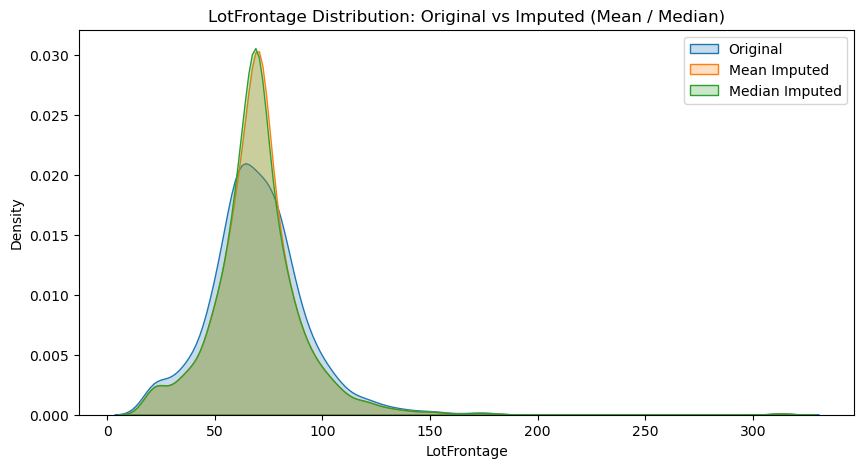

In [33]:
plt.figure(figsize=(10,5))
# kdeplot --> plot that shows pdf
sns.kdeplot(df["LotFrontage"], label="Original", fill=True)
sns.kdeplot(df_mean["LotFrontage"], label="Mean Imputed", fill=True)
sns.kdeplot(df_median["LotFrontage"], label="Median Imputed", fill=True)
plt.legend()
plt.title("LotFrontage Distribution: Original vs Imputed (Mean / Median)")
plt.show()

In [34]:
#Class version
def compare_imputation(df_before, df_after, column_name):
    missing_indices = {column_name : df_before[df_before[column_name].isnull()].index.to_list() 
    for column_name in df_before.columns if df_before[column_name].isnull().any()}

    if column_name not in missing_indices:
        print(f"No missing values were found in column '{column_name}'")
        return

    idx_list = missing_indices[column_name]

    comparison = pd.DataFrame({
        "Before" : df_before.loc[idx_list,column_name], 
        "After" : df_after.loc[idx_list,column_name], 
    })

    print(f"Changes in column : {column_name}")
    return comparison

In [35]:
# Other  version
def compare_imputation_new(df_before, df_after, column_name):
    idx_list = df_before[df_before[column_name].isnull()].index.to_list()

    if not idx_list:
        print(f"No missing values were found in column '{column_name}'")
        return

    comparison = pd.DataFrame({
        "Before": df_before.loc[idx_list, column_name],
        "After": df_after.loc[idx_list, column_name]
    })

    print(f"Changes in column : {column_name}")
    return comparison

In [36]:
idx_list = df_3[df_3["LotFrontage"].isnull()].index.to_list()
idx_list

[7,
 12,
 14,
 16,
 24,
 31,
 42,
 43,
 50,
 64,
 66,
 76,
 84,
 95,
 100,
 104,
 111,
 113,
 116,
 120,
 126,
 131,
 133,
 136,
 147,
 149,
 152,
 153,
 160,
 166,
 169,
 170,
 177,
 180,
 186,
 191,
 203,
 207,
 208,
 214,
 218,
 221,
 234,
 237,
 244,
 249,
 269,
 287,
 288,
 293,
 307,
 308,
 310,
 319,
 328,
 330,
 335,
 342,
 346,
 347,
 351,
 356,
 360,
 361,
 364,
 366,
 369,
 370,
 375,
 384,
 392,
 393,
 404,
 405,
 412,
 421,
 426,
 447,
 452,
 457,
 458,
 459,
 465,
 470,
 484,
 490,
 496,
 516,
 518,
 529,
 537,
 538,
 539,
 541,
 545,
 559,
 560,
 564,
 569,
 580,
 593,
 610,
 611,
 612,
 616,
 623,
 626,
 641,
 645,
 660,
 666,
 668,
 672,
 679,
 682,
 685,
 687,
 690,
 706,
 709,
 714,
 720,
 721,
 726,
 734,
 745,
 746,
 751,
 757,
 770,
 783,
 785,
 789,
 791,
 794,
 811,
 816,
 817,
 822,
 828,
 840,
 845,
 851,
 853,
 855,
 856,
 859,
 865,
 868,
 879,
 882,
 893,
 900,
 904,
 908,
 911,
 917,
 925,
 927,
 928,
 929,
 939,
 941,
 944,
 953,
 961,
 967,
 975,
 980,
 

In [37]:
missing_indices = {"LotFrontage" : df_3[df_3["LotFrontage"].isnull()].index.to_list() for column_name in df_3.columns if df_3["LotFrontage"].isnull().any()}
missing_indices

{'LotFrontage': [7,
  12,
  14,
  16,
  24,
  31,
  42,
  43,
  50,
  64,
  66,
  76,
  84,
  95,
  100,
  104,
  111,
  113,
  116,
  120,
  126,
  131,
  133,
  136,
  147,
  149,
  152,
  153,
  160,
  166,
  169,
  170,
  177,
  180,
  186,
  191,
  203,
  207,
  208,
  214,
  218,
  221,
  234,
  237,
  244,
  249,
  269,
  287,
  288,
  293,
  307,
  308,
  310,
  319,
  328,
  330,
  335,
  342,
  346,
  347,
  351,
  356,
  360,
  361,
  364,
  366,
  369,
  370,
  375,
  384,
  392,
  393,
  404,
  405,
  412,
  421,
  426,
  447,
  452,
  457,
  458,
  459,
  465,
  470,
  484,
  490,
  496,
  516,
  518,
  529,
  537,
  538,
  539,
  541,
  545,
  559,
  560,
  564,
  569,
  580,
  593,
  610,
  611,
  612,
  616,
  623,
  626,
  641,
  645,
  660,
  666,
  668,
  672,
  679,
  682,
  685,
  687,
  690,
  706,
  709,
  714,
  720,
  721,
  726,
  734,
  745,
  746,
  751,
  757,
  770,
  783,
  785,
  789,
  791,
  794,
  811,
  816,
  817,
  822,
  828,
  840,
  845,
  851,

#### KNN

In [38]:
df_knn=df_3.copy()

In [39]:
from sklearn.impute import KNNImputer

In [40]:

knn_imputer = KNNImputer(n_neighbors=5)

In [41]:
numerical_cols = df_knn.select_dtypes(include=[np.number]).columns
numerical_cols

Index(['LotFrontage', 'LotArea', 'OverallQual', 'YearBuilt', 'YearRemodAdd',
       'MasVnrArea', 'BsmtFinSF1', 'BsmtUnfSF', 'TotalBsmtSF', '2ndFlrSF',
       'GrLivArea', 'BsmtFullBath', 'FullBath', 'HalfBath', 'BedroomAbvGr',
       'KitchenAbvGr', 'Fireplaces', 'GarageCars', 'WoodDeckSF', 'OpenPorchSF',
       'EnclosedPorch', 'ScreenPorch', 'SalePrice'],
      dtype='object')

In [42]:
df_knn[numerical_cols] = knn_imputer.fit_transform(df_knn[numerical_cols])

In [43]:
compare_imputation_new(df_3,df_knn,"LotFrontage").head(10)

Changes in column : LotFrontage


,Before,After
7,NaN,77.4
12,NaN,73.2
14,NaN,75.2
16,NaN,90.2
24,NaN,66.0
31,NaN,68.4
42,NaN,69.6
43,NaN,70.6
50,NaN,77.8
64,NaN,76.4


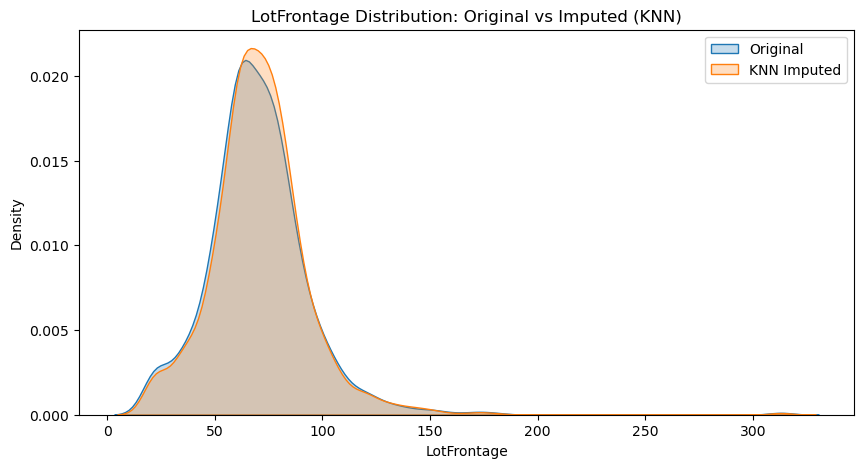

In [44]:
plt.figure(figsize=(10,5))
# kdeplot --> plot that shows pdf
sns.kdeplot(df["LotFrontage"], label="Original", fill=True)
sns.kdeplot(df_knn["LotFrontage"], label="KNN Imputed", fill=True)
plt.legend()
plt.title("LotFrontage Distribution: Original vs Imputed (KNN)")
plt.show()

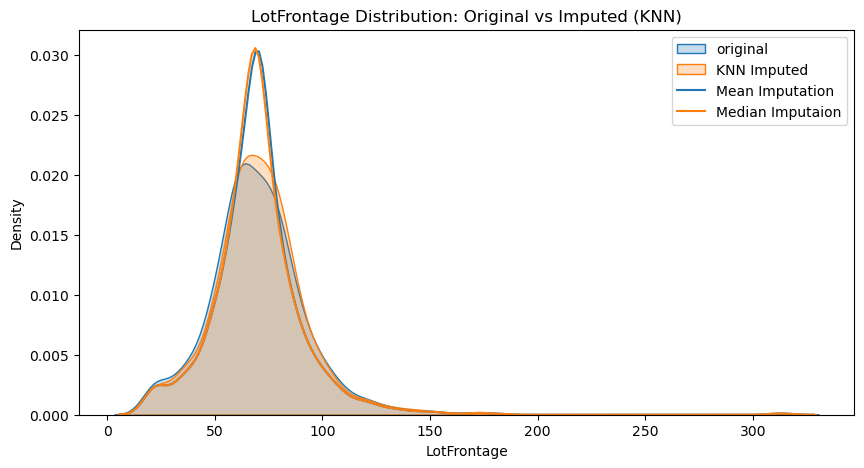

In [45]:
plt.figure(figsize=(10,5))
sns.kdeplot(df["LotFrontage"],label="original",fill=True)
sns.kdeplot(df_knn["LotFrontage"],label="KNN Imputed",fill=True)
sns.kdeplot(df_mean["LotFrontage"],label="Mean Imputation",fill=False)
sns.kdeplot(df_median["LotFrontage"],label="Median Imputaion",fill=False)
plt.title("LotFrontage Distribution: Original vs Imputed (KNN)")
plt.legend()
plt.show()

### Regression Imputation (Advanced)

In [46]:
from sklearn.linear_model import LinearRegression

In [47]:
df_reg = df_3.copy()

In [48]:
train_data = df_reg.dropna(subset=["LotFrontage"]) # drop the rows where LotFrontage has null values
test_data = df_reg[df_reg["LotFrontage"].isnull()]

In [51]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1201 entries, 0 to 1459
Data columns (total 62 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSZoning       1201 non-null   object 
 1   LotFrontage    1201 non-null   float64
 2   LotArea        1201 non-null   int64  
 3   Street         1201 non-null   object 
 4   LotShape       1201 non-null   object 
 5   LandContour    1201 non-null   object 
 6   Utilities      1201 non-null   object 
 7   LotConfig      1201 non-null   object 
 8   LandSlope      1201 non-null   object 
 9   Neighborhood   1201 non-null   object 
 10  Condition1     1201 non-null   object 
 11  Condition2     1201 non-null   object 
 12  BldgType       1201 non-null   object 
 13  HouseStyle     1201 non-null   object 
 14  OverallQual    1201 non-null   int64  
 15  YearBuilt      1201 non-null   int64  
 16  YearRemodAdd   1201 non-null   int64  
 17  RoofStyle      1201 non-null   object 
 18  RoofMatl     

In [52]:
target_coorelation_ml = train_data.select_dtypes(include=[np.number]).corr()['LotFrontage'].abs()
target_coorelation_ml

LotFrontage      1.000000
LotArea          0.426095
OverallQual      0.251646
YearBuilt        0.123349
YearRemodAdd     0.088866
MasVnrArea       0.193458
BsmtFinSF1       0.233633
BsmtUnfSF        0.132644
TotalBsmtSF      0.392075
2ndFlrSF         0.080177
GrLivArea        0.402797
BsmtFullBath     0.100949
FullBath         0.198769
HalfBath         0.053532
BedroomAbvGr     0.263170
KitchenAbvGr     0.006069
Fireplaces       0.266639
GarageCars       0.285691
WoodDeckSF       0.088521
OpenPorchSF      0.151972
EnclosedPorch    0.010700
ScreenPorch      0.041383
SalePrice        0.351799
Name: LotFrontage, dtype: float64

In [53]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1201 entries, 0 to 1459
Data columns (total 62 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSZoning       1201 non-null   object 
 1   LotFrontage    1201 non-null   float64
 2   LotArea        1201 non-null   int64  
 3   Street         1201 non-null   object 
 4   LotShape       1201 non-null   object 
 5   LandContour    1201 non-null   object 
 6   Utilities      1201 non-null   object 
 7   LotConfig      1201 non-null   object 
 8   LandSlope      1201 non-null   object 
 9   Neighborhood   1201 non-null   object 
 10  Condition1     1201 non-null   object 
 11  Condition2     1201 non-null   object 
 12  BldgType       1201 non-null   object 
 13  HouseStyle     1201 non-null   object 
 14  OverallQual    1201 non-null   int64  
 15  YearBuilt      1201 non-null   int64  
 16  YearRemodAdd   1201 non-null   int64  
 17  RoofStyle      1201 non-null   object 
 18  RoofMatl     

In [54]:
X_train = train_data[["LotArea", "OverallQual", "TotalBsmtSF", "GrLivArea"]]
y_train = train_data["LotFrontage"]

In [55]:
reg = LinearRegression()

In [56]:
reg.fit(X_train, y_train)

LinearRegression()

In [57]:
test_data.head(1)

,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,...,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,ScreenPorch,SaleType,SaleCondition,SalePrice
7,RL,NaN,10382,Pave,IR1,Lvl,AllPub,Corner,Gtl,NWAmes,...,TA,TA,Y,235,204,228,0,WD,Normal,200000


In [59]:
test_data[["LotArea", "OverallQual", "TotalBsmtSF", "GrLivArea"]].info()

<class 'pandas.core.frame.DataFrame'>
Index: 259 entries, 7 to 1446
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   LotArea      259 non-null    int64
 1   OverallQual  259 non-null    int64
 2   TotalBsmtSF  259 non-null    int64
 3   GrLivArea    259 non-null    int64
dtypes: int64(4)
memory usage: 10.1 KB


In [60]:
df_reg["LotFrontage"].isnull().head(10)

0    False
1    False
2    False
3    False
4    False
5    False
6    False
7     True
8    False
9    False
Name: LotFrontage, dtype: bool

In [64]:
train_data.head(10)

,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,...,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,ScreenPorch,SaleType,SaleCondition,SalePrice
0,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,...,TA,TA,Y,0,61,0,0,WD,Normal,208500
1,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,Veenker,...,TA,TA,Y,298,0,0,0,WD,Normal,181500
2,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,...,TA,TA,Y,0,42,0,0,WD,Normal,223500
3,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,...,TA,TA,Y,0,35,272,0,WD,Abnorml,140000
4,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,...,TA,TA,Y,192,84,0,0,WD,Normal,250000
5,RL,85.0,14115,Pave,IR1,Lvl,AllPub,Inside,Gtl,Mitchel,...,TA,TA,Y,40,30,0,0,WD,Normal,143000
6,RL,75.0,10084,Pave,Reg,Lvl,AllPub,Inside,Gtl,Somerst,...,TA,TA,Y,255,57,0,0,WD,Normal,307000
8,RM,51.0,6120,Pave,Reg,Lvl,AllPub,Inside,Gtl,OldTown,...,Fa,TA,Y,90,0,205,0,WD,Abnorml,129900
9,RL,50.0,7420,Pave,Reg,Lvl,AllPub,Corner,Gtl,BrkSide,...,Gd,TA,Y,0,4,0,0,WD,Normal,118000
10,RL,70.0,11200,Pave,Reg,Lvl,AllPub,Inside,Gtl,Sawyer,...,TA,TA,Y,0,0,0,0,WD,Normal,129500


In [71]:
df_reg.loc[df_reg["LotFrontage"].isnull(),"LotFrontage"]=reg.predict(test_data[["LotArea", "OverallQual", "TotalBsmtSF", "GrLivArea"]])

In [74]:
compare_imputation(df_3, df_reg, "LotFrontage").head(10)

Changes in column : LotFrontage


,Before,After
7,NaN,76.480215
12,NaN,65.575403
14,NaN,70.486403
16,NaN,64.762909
24,NaN,64.943935
31,NaN,69.263614
42,NaN,60.980342
43,NaN,62.848844
50,NaN,69.936893
64,NaN,74.307034


AttributeError: module 'seaborn' has no attribute 'title'

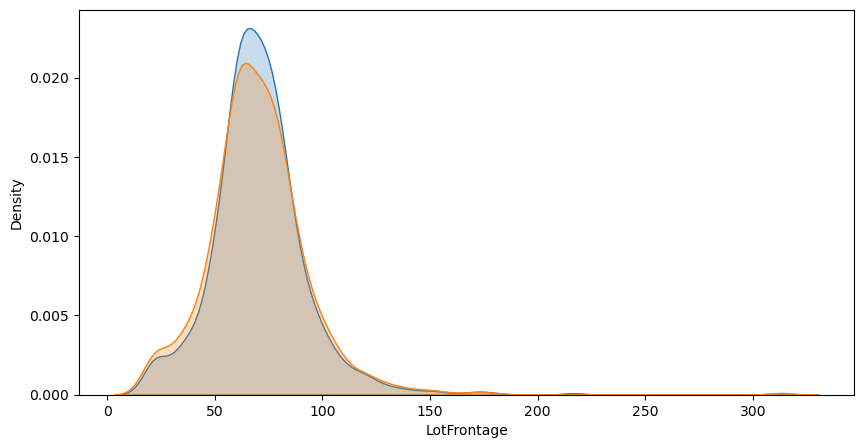

In [ ]:
plt.figure(figsize=(10,5))
sns.kdeplot(df_reg["LotFrontage"],label="LotFrontage Linear",fill=True)
sns.kdeplot(df_3["LotFrontage"],label="Original",fill=True)
plt.title("Comparision of Original vs Linear Regression Imputation")
plt.legend()
plt.show()
